# Chapter 10 - Gaussian Mixture Model

## 1. Gaussian Example

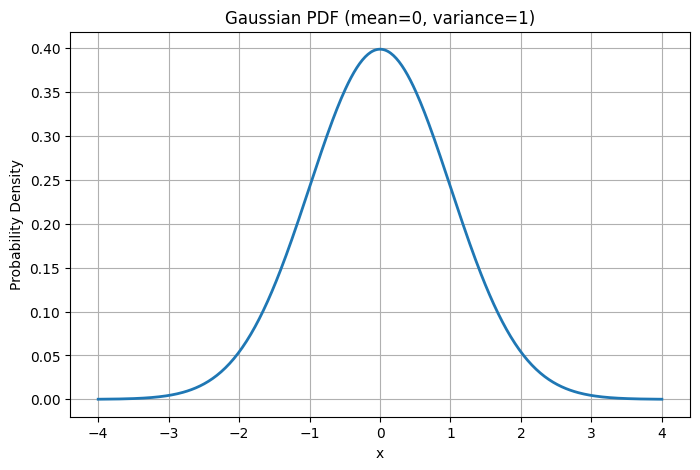

In [1]:
# Gaussian
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 0           # mean
sigma = 1        # standard deviation
variance = sigma**2

# Generate x range
# Tạo 400 điểm trải đều từ μ−4σ đến μ+4σ dùng làm trục x 
# để vẽ đường cong Gaussian mượt đẹp
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

# Gaussian PDF formula
pdf = (1 / np.sqrt(2 * np.pi * variance)) * np.exp(- (x - mu)**2 / (2 * variance))

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, pdf, linewidth=2)
plt.title("Gaussian PDF (mean=0, variance=1)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()

## 2. Gaussian Mixture Model

In [2]:
# Generating Synthetic Data
import numpy as np

# Parameters derived from the example
mu = [-1, 0, 3]
sigma_sq = [2.25, 1, 0.25]
weights = [0.3, 0.5, 0.2]

N_samples = 1000
N1 = int(N_samples * weights[0]) # 300 samples
N2 = int(N_samples * weights[1]) # 500 samples
N3 = int(N_samples * weights[2]) # 200 samples

# Generate samples from each 1D Gaussian
comp_1 = np.random.normal(mu[0], np.sqrt(sigma_sq[0]), N1)
comp_2 = np.random.normal(mu[1], np.sqrt(sigma_sq[1]), N2)
comp_3 = np.random.normal(mu[2], np.sqrt(sigma_sq[2]), N3)

# Combine into the input dataset X
X = np.concatenate([comp_1, comp_2, comp_3])

In [3]:
# Fitting the Mixed Distribution Model
from sklearn.mixture import GaussianMixture
# X must be reshaped for scikit-learn compatibility (N samples, 1 feature)
X = X.reshape(-1, 1)

# Fit GMM model with 3 components (K=3)
# The EM algorithm works internally here to find optimal mu, sigma, and weights.
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# The model 'gmm' now contains the learned mean, covariance, and weights

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [4]:
# cluster labeling
labels = gmm.predict(X)
print(labels)

[2 0 1 2 2 2 1 1 1 1 1 2 1 1 1 1 2 2 2 1 1 1 2 0 2 1 2 2 2 2 1 1 1 1 1 1 1
 0 1 1 2 1 1 2 2 2 1 1 1 2 1 2 1 1 1 2 2 2 1 2 2 1 2 2 1 2 2 1 2 1 1 0 1 2
 2 1 1 1 2 1 2 2 2 2 2 1 2 1 2 1 1 2 2 1 1 2 1 1 2 2 2 2 2 1 1 0 1 2 2 1 1
 2 2 2 1 1 2 1 2 1 1 2 2 1 2 2 1 1 1 2 1 2 1 2 2 1 1 1 2 2 1 1 2 1 2 1 2 1
 1 2 1 1 2 2 2 2 2 1 2 1 1 1 1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 2 1 2 1 1 1 2
 2 2 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 1 1 1 2 1 2 1 2 1 1 1 1 0 2 1 1 2
 1 1 2 1 2 2 1 2 1 2 1 1 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 1 2 2 2 1 1 2 1 1 1
 2 2 2 1 0 2 2 0 2 2 1 1 2 2 2 2 1 1 2 2 1 2 2 1 1 2 1 2 2 2 1 2 2 2 2 2 1
 2 2 2 2 2 2 0 2 2 2 0 2 2 1 2 1 2 2 2 2 2 2 2 2 2 2 1 2 2 1 1 1 0 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 0 1 2 2 2 2 2 1 0 1 2 2 1 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 1 2 2 2 1 2 2 2 2 2 2 2 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 1 2 2 2 2 2 2 0 2 2 2 2 2 2 1
 1 2 2 1 2 2 2 1 0 2 2 2 

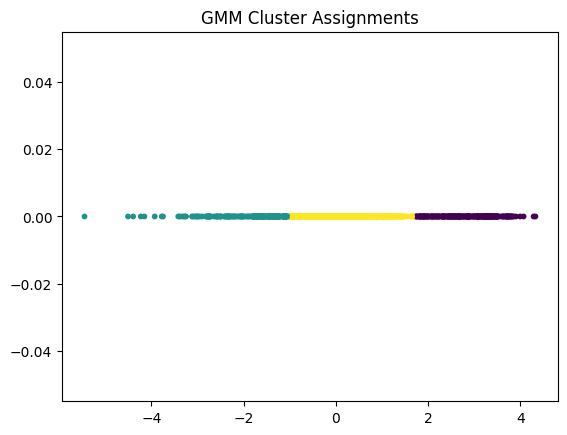

In [5]:
# Plot Clusters
import matplotlib.pyplot as plt
plt.scatter(X, np.zeros_like(X), c=labels, s=10)
plt.title("GMM Cluster Assignments")
plt.show()

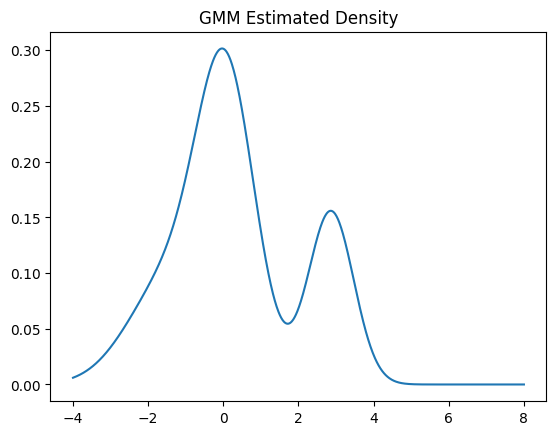

In [6]:
# Plot the PDF of GMM
# Tạo dãy giá trị x từ -4 đến 8 gồm 1000 điểm
# reshape(-1, 1): chuyển thành vector cột để đưa vào GMM
xs = np.linspace(-4, 8, 1000).reshape(-1, 1)

# Tính mật độ (density) mà GMM ước lượng tại mỗi điểm x
density = np.exp(gmm.score_samples(xs))
# Vẽ đồ thị mật độ PDF của GMM
plt.plot(xs, density)
plt.title("GMM Estimated Density")
plt.show()